In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [3]:
medal_distribution_2024 = pd.read_csv('../data/raw/medalists_data_raw.csv')
medal_distribution_2024.head()

,medal_date,medal_type,medal_code,name,gender,country_code,country,country_long,nationality_code,nationality,...,team,team_gender,discipline,event,event_type,url_event,birth_date,code_athlete,code_team,is_medallist
0,2024-07-27,Gold Medal,1.0,EVENEPOEL Remco,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,2000-01-25,1903136,NaN,True
1,2024-07-27,Silver Medal,2.0,GANNA Filippo,Male,ITA,Italy,Italy,ITA,Italy,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1996-07-25,1923520,NaN,True
2,2024-07-27,Bronze Medal,3.0,van AERT Wout,Male,BEL,Belgium,Belgium,BEL,Belgium,...,NaN,NaN,Cycling Road,Men's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/men-s-indi...,1994-09-15,1903147,NaN,True
3,2024-07-27,Gold Medal,1.0,BROWN Grace,Female,AUS,Australia,Australia,AUS,Australia,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1992-07-07,1940173,NaN,True
4,2024-07-27,Silver Medal,2.0,HENDERSON Anna,Female,GBR,Great Britain,Great Britain,GBR,Great Britain,...,NaN,NaN,Cycling Road,Women's Individual Time Trial,ATH,/en/paris-2024/results/cycling-road/women-s-in...,1998-11-14,1912525,NaN,True


In [4]:
medal_distribution_2024 = medal_distribution_2024[['medal_date', 'medal_type', 'country_code',
                                                   'country', 'discipline', 'event', 'code_team']]
medal_distribution_2024.head()

,medal_date,medal_type,country_code,country,discipline,event,code_team
0,2024-07-27,Gold Medal,BEL,Belgium,Cycling Road,Men's Individual Time Trial,NaN
1,2024-07-27,Silver Medal,ITA,Italy,Cycling Road,Men's Individual Time Trial,NaN
2,2024-07-27,Bronze Medal,BEL,Belgium,Cycling Road,Men's Individual Time Trial,NaN
3,2024-07-27,Gold Medal,AUS,Australia,Cycling Road,Women's Individual Time Trial,NaN
4,2024-07-27,Silver Medal,GBR,Great Britain,Cycling Road,Women's Individual Time Trial,NaN


In [5]:
medal_distribution_2024.shape

(2315, 7)

In [6]:
duplicate_rows = medal_distribution_2024[medal_distribution_2024.duplicated()]
duplicate_rows

,medal_date,medal_type,country_code,country,discipline,event,code_team
761,2024-07-27,Gold Medal,CHN,China,Diving,Women's Synchronised 3m Springboard,DIVW3MTEAM2-CHN01
763,2024-07-27,Silver Medal,USA,United States,Diving,Women's Synchronised 3m Springboard,DIVW3MTEAM2-USA01
765,2024-07-27,Bronze Medal,GBR,Great Britain,Diving,Women's Synchronised 3m Springboard,DIVW3MTEAM2-GBR01
767,2024-07-27,Gold Medal,FRA,France,Rugby Sevens,Men,RU7MTEAM7---FRA01
768,2024-07-27,Gold Medal,FRA,France,Rugby Sevens,Men,RU7MTEAM7---FRA01
...,...,...,...,...,...,...,...
2309,2024-08-10,Silver Medal,ISR,Israel,Rhythmic Gymnastics,Group All-Around,GRYW5AA-----ISR01
2311,2024-08-10,Bronze Medal,ITA,Italy,Rhythmic Gymnastics,Group All-Around,GRYW5AA-----ITA01
2312,2024-08-10,Bronze Medal,ITA,Italy,Rhythmic Gymnastics,Group All-Around,GRYW5AA-----ITA01
2313,2024-08-10,Bronze Medal,ITA,Italy,Rhythmic Gymnastics,Group All-Around,GRYW5AA-----ITA01


In [7]:
medal_distribution_2024 = medal_distribution_2024.drop_duplicates(keep='first')
medal_distribution_2024.head()

,medal_date,medal_type,country_code,country,discipline,event,code_team
0,2024-07-27,Gold Medal,BEL,Belgium,Cycling Road,Men's Individual Time Trial,NaN
1,2024-07-27,Silver Medal,ITA,Italy,Cycling Road,Men's Individual Time Trial,NaN
2,2024-07-27,Bronze Medal,BEL,Belgium,Cycling Road,Men's Individual Time Trial,NaN
3,2024-07-27,Gold Medal,AUS,Australia,Cycling Road,Women's Individual Time Trial,NaN
4,2024-07-27,Silver Medal,GBR,Great Britain,Cycling Road,Women's Individual Time Trial,NaN


In [8]:
medal_distribution_2024.shape

(1044, 7)

In [9]:
medal_distribution_2024_cc = medal_distribution_2024[['country_code', 'country']]
medal_distribution_2024_cc.head()

,country_code,country
0,BEL,Belgium
1,ITA,Italy
2,BEL,Belgium
3,AUS,Australia
4,GBR,Great Britain


In [10]:
medal_distribution_2024 = medal_distribution_2024[['country', 'medal_type']]
medal_distribution_2024.head()

,country,medal_type
0,Belgium,Gold Medal
1,Italy,Silver Medal
2,Belgium,Bronze Medal
3,Australia,Gold Medal
4,Great Britain,Silver Medal


In [11]:
medal_distribution_2024 = medal_distribution_2024.pivot_table(index='country', columns='medal_type',
                                                              aggfunc='size', fill_value=0)
medal_distribution_2024

medal_type,Bronze Medal,Gold Medal,Silver Medal
country,,,
AIN,1,1,3
Albania,2,0,0
Algeria,1,2,0
Argentina,1,1,1
Armenia,1,0,3
...,...,...,...
Uganda,0,1,1
Ukraine,4,3,5
United States,42,40,44


In [12]:
medal_distribution_2024 = medal_distribution_2024[['Gold Medal', 'Silver Medal', 'Bronze Medal']].copy()
medal_distribution_2024

medal_type,Gold Medal,Silver Medal,Bronze Medal
country,,,
AIN,1,3,1
Albania,0,0,2
Algeria,2,0,1
Argentina,1,1,1
Armenia,0,3,1
...,...,...,...
Uganda,1,1,0
Ukraine,3,5,4
United States,40,44,42


In [13]:
medal_distribution_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, AIN to Zambia
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Gold Medal    92 non-null     int64
 1   Silver Medal  92 non-null     int64
 2   Bronze Medal  92 non-null     int64
dtypes: int64(3)
memory usage: 2.9+ KB


In [14]:
world_population_gdp_2024 = pd.read_csv("../data/raw/world_gdp_data_raw.csv")
world_population_gdp_2024.head()

,population,id,imfGDP,unGDP,country,gdpPerCapita,continent,rank
0,345426571,840,2.878108e+13,25744100000000,United States,83320.399808,North America,1
1,1419321278,156,1.853263e+13,17963170521080,China,13057.388970,Asia,2
2,84552242,276,4.591100e+12,4076923618912,Germany,54298.974118,Europe,3
3,123753041,392,4.110450e+12,4232173916087,Japan,33214.941361,Asia,4
4,1450935791,356,3.937010e+12,3465541446546,India,2713.428137,Asia,5


In [15]:
world_population_gdp_2024 = world_population_gdp_2024[['country', 'population', 'gdpPerCapita']]
world_population_gdp_2024.head()

,country,population,gdpPerCapita
0,United States,345426571,83320.399808
1,China,1419321278,13057.388970
2,Germany,84552242,54298.974118
3,Japan,123753041,33214.941361
4,India,1450935791,2713.428137


In [16]:
world_population_gdp_2024.set_index('country', inplace=True)
world_population_gdp_2024.head()

,population,gdpPerCapita
country,,
United States,345426571,83320.399808
China,1419321278,13057.388970
Germany,84552242,54298.974118
Japan,123753041,33214.941361
India,1450935791,2713.428137


In [17]:
world_population_gdp_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, United States to Turks and Caicos Islands
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   population    212 non-null    int64  
 1   gdpPerCapita  212 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 5.0+ KB


In [18]:
# To merge the two dataframes, keeping all rows from medal_distribution_2024
# and only matching rows from world_population_gdp_2024:

medals_population_gdp_2024 = medal_distribution_2024.merge(world_population_gdp_2024,
                                                           left_index=True, right_index=True,
                                                           how='left')
medals_population_gdp_2024

,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita
country,,,,,
AIN,1,3,1,NaN,NaN
Albania,0,0,2,2791765.0,9109.291076
Algeria,2,0,1,46814308.0,5698.685111
Argentina,1,1,1,45696159.0,13223.430880
Armenia,0,3,1,2973840.0,8543.835580
...,...,...,...,...,...
Uganda,1,1,0,50015092.0,1125.860170
Ukraine,3,5,4,37860221.0,4990.541392
United States,40,44,42,345426571.0,83320.399808


In [19]:
medals_population_gdp_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, AIN to Zambia
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gold Medal    92 non-null     int64  
 1   Silver Medal  92 non-null     int64  
 2   Bronze Medal  92 non-null     int64  
 3   population    79 non-null     float64
 4   gdpPerCapita  79 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 4.3+ KB


In [20]:
null_values_population_gdp = medals_population_gdp_2024[medals_population_gdp_2024['population'].isnull() &
                                                        medals_population_gdp_2024['gdpPerCapita'].isnull()]
null_values_population_gdp

,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita
country,,,,,
AIN,1,3,1,NaN,NaN
Cabo Verde,0,0,1,NaN,NaN
Chinese Taipei,2,0,5,NaN,NaN
Czechia,3,0,2,NaN,NaN
Côte d'Ivoire,0,0,1,NaN,NaN
DPR Korea,0,2,4,NaN,NaN
EOR,0,0,1,NaN,NaN
Great Britain,14,22,29,NaN,NaN
"Hong Kong, China",2,0,2,NaN,NaN


In [21]:
null_values_population_gdp.shape[0] # 92 - 79 = 13

13

In [22]:
medals_population_gdp_2024.loc['Cabo Verde', 'population'] = 524877
medals_population_gdp_2024.loc['Cabo Verde', 'gdpPerCapita'] = 5178.35607199401

medals_population_gdp_2024.loc['Chinese Taipei', 'population'] = 23213962
medals_population_gdp_2024.loc['Chinese Taipei', 'gdpPerCapita'] = 34589.4423364698

medals_population_gdp_2024.loc['Czechia', 'population'] = 10735859
medals_population_gdp_2024.loc['Czechia', 'gdpPerCapita'] = 30354.3479846373

medals_population_gdp_2024.loc["Côte d'Ivoire", 'population'] = 31934230
medals_population_gdp_2024.loc["Côte d'Ivoire", 'gdpPerCapita'] = 2721.56241124336

medals_population_gdp_2024.loc['DPR Korea', 'population'] = 26498823
medals_population_gdp_2024.loc['DPR Korea', 'gdpPerCapita'] = 572.709761976975

medals_population_gdp_2024.loc['Great Britain', 'population'] = 69138192
medals_population_gdp_2024.loc['Great Britain', 'gdpPerCapita'] = 50554.6919711178

medals_population_gdp_2024.loc['Hong Kong, China', 'population'] = 7414909
medals_population_gdp_2024.loc['Hong Kong, China', 'gdpPerCapita'] = 54859.0683985468

medals_population_gdp_2024.loc['IR Iran', 'population'] = 91567738
medals_population_gdp_2024.loc['IR Iran', 'gdpPerCapita'] = 5069.26358713808

medals_population_gdp_2024.loc['Korea', 'population'] = 51717590
medals_population_gdp_2024.loc['Korea', 'gdpPerCapita'] = 34049.3437532569

medals_population_gdp_2024.loc['Republic of Moldova', 'population'] = 3034961
medals_population_gdp_2024.loc['Republic of Moldova', 'gdpPerCapita'] = 6048.18315622507

medals_population_gdp_2024.loc['Türkiye', 'population'] = 87473805
medals_population_gdp_2024.loc['Türkiye', 'gdpPerCapita'] = 12730.2110614715

In [23]:
null_values_population_gdp = medals_population_gdp_2024[medals_population_gdp_2024['population'].isnull() &
                                                        medals_population_gdp_2024['gdpPerCapita'].isnull()]
null_values_population_gdp

,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita
country,,,,,
AIN,1,3,1,NaN,NaN
EOR,0,0,1,NaN,NaN


**EOR** (*Équipe Olympique des Réfugiés*): The French term for the **Refugee Olympic Team**, which consists of athletes who are refugees and compete under the Olympic flag.

**AIN** (*Athlètes Individuels Neutres*): The French term for **Individual Neutral Athletes**, referring to Russian and Belarusian athletes competing without national symbols at the 2024 Paris Olympics due to their countries’ involvement in the Ukraine conflict.

In [25]:
medals_population_gdp_2024 = medals_population_gdp_2024.drop(index=['AIN', 'EOR'])
medals_population_gdp_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 90 entries, Albania to Zambia
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Gold Medal    90 non-null     int64  
 1   Silver Medal  90 non-null     int64  
 2   Bronze Medal  90 non-null     int64  
 3   population    90 non-null     float64
 4   gdpPerCapita  90 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 4.2+ KB


In [26]:
medals_population_gdp_2024

,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita
country,,,,,
Albania,0,0,2,2791765.0,9109.291076
Algeria,2,0,1,46814308.0,5698.685111
Argentina,1,1,1,45696159.0,13223.430880
Armenia,0,3,1,2973840.0,8543.835580
Australia,18,19,16,26713205.0,67021.160508
...,...,...,...,...,...
Uganda,1,1,0,50015092.0,1125.860170
Ukraine,3,5,4,37860221.0,4990.541392
United States,40,44,42,345426571.0,83320.399808


In [27]:
folder_path = '../data/processed/'
file_name = 'medals_population_gdp_2024_processed.csv'
full_path = folder_path + file_name
medals_population_gdp_2024.to_csv(full_path)

In [28]:
medal_distribution_2024_processed = pd.read_csv('../data/processed/medals_population_gdp_2024_processed.csv')

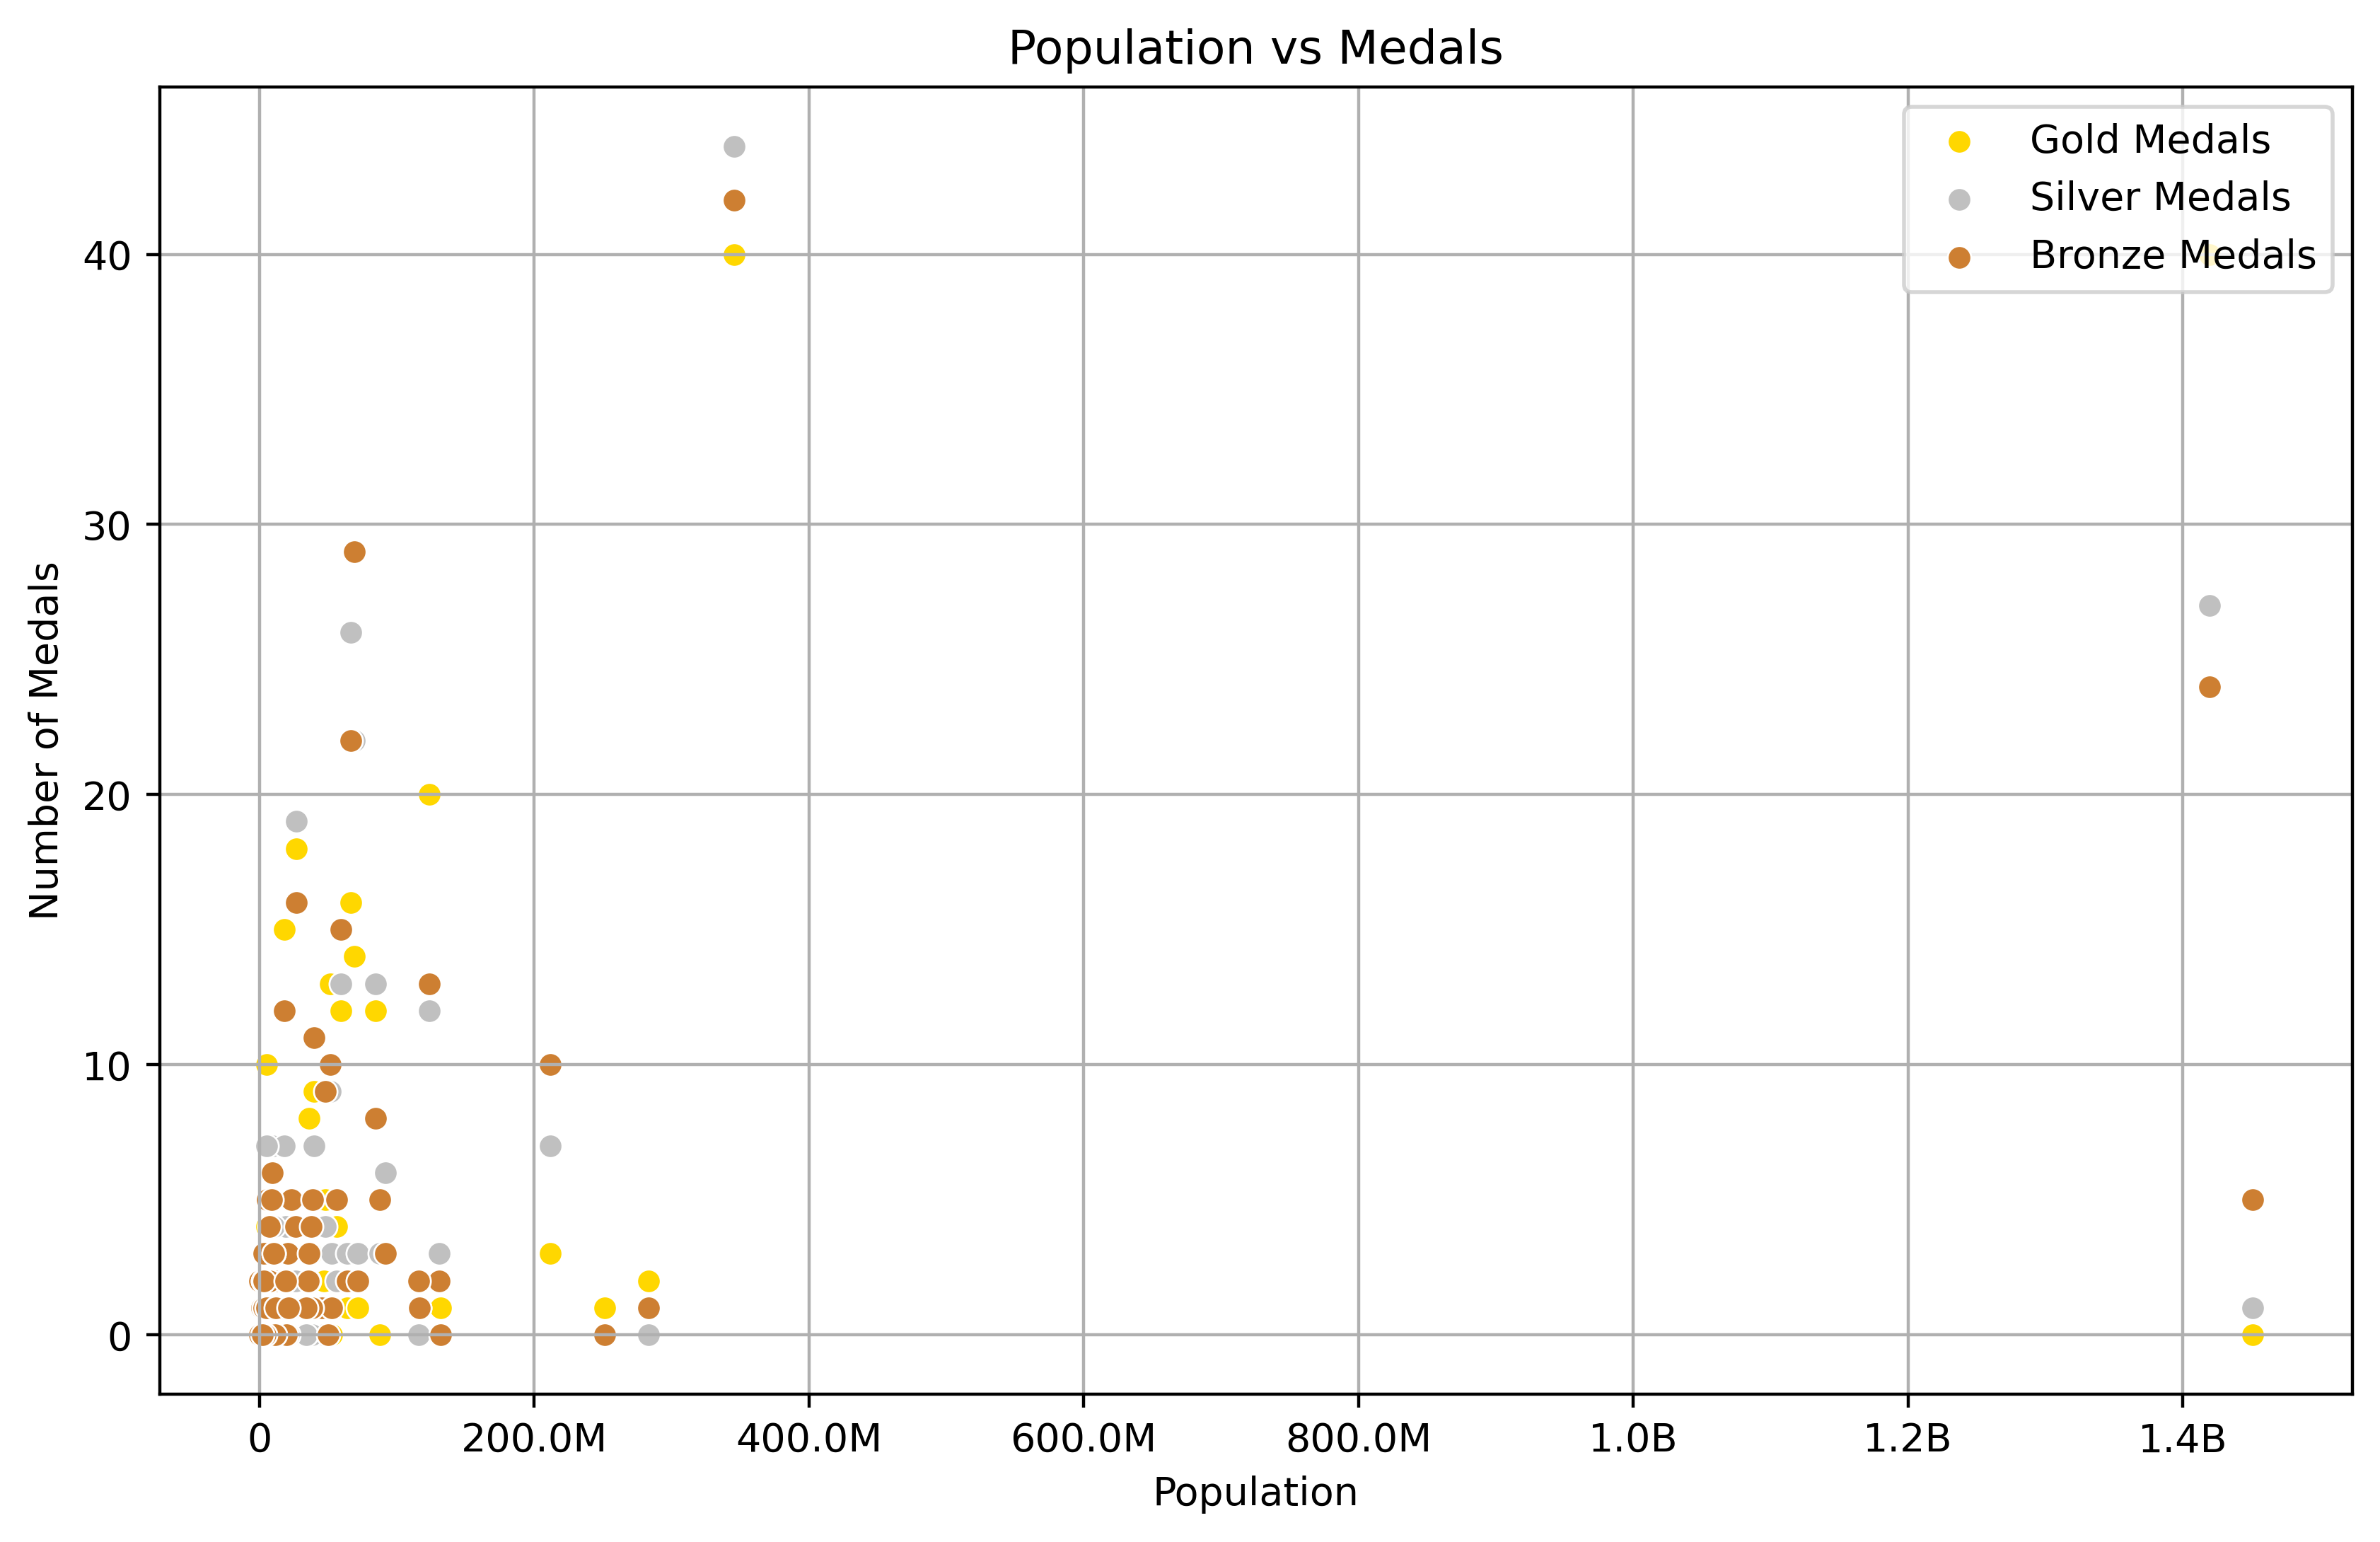

In [29]:
from matplotlib.ticker import FuncFormatter

def format_population(x, pos):
    if x >= 1e9:
        return f'{x * 1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x * 1e-6:.1f}M'
    else:
        return f'{x:.0f}'

plt.figure(figsize=(10,6))
sns.scatterplot(x='population', y='Gold Medal', color='#FFD700',
                data=medals_population_gdp_2024, label='Gold Medals')
sns.scatterplot(x='population', y='Silver Medal', color='#C0C0C0',
                data=medals_population_gdp_2024, label='Silver Medals')
sns.scatterplot(x='population', y='Bronze Medal', color='#CD7F32',
                data=medals_population_gdp_2024, label='Bronze Medals')
plt.gca().xaxis.set_major_formatter(FuncFormatter(format_population))
plt.title('Population vs Medals')
plt.xlabel('Population')
plt.ylabel('Number of Medals')
plt.legend(loc='upper right')
plt.grid(True)

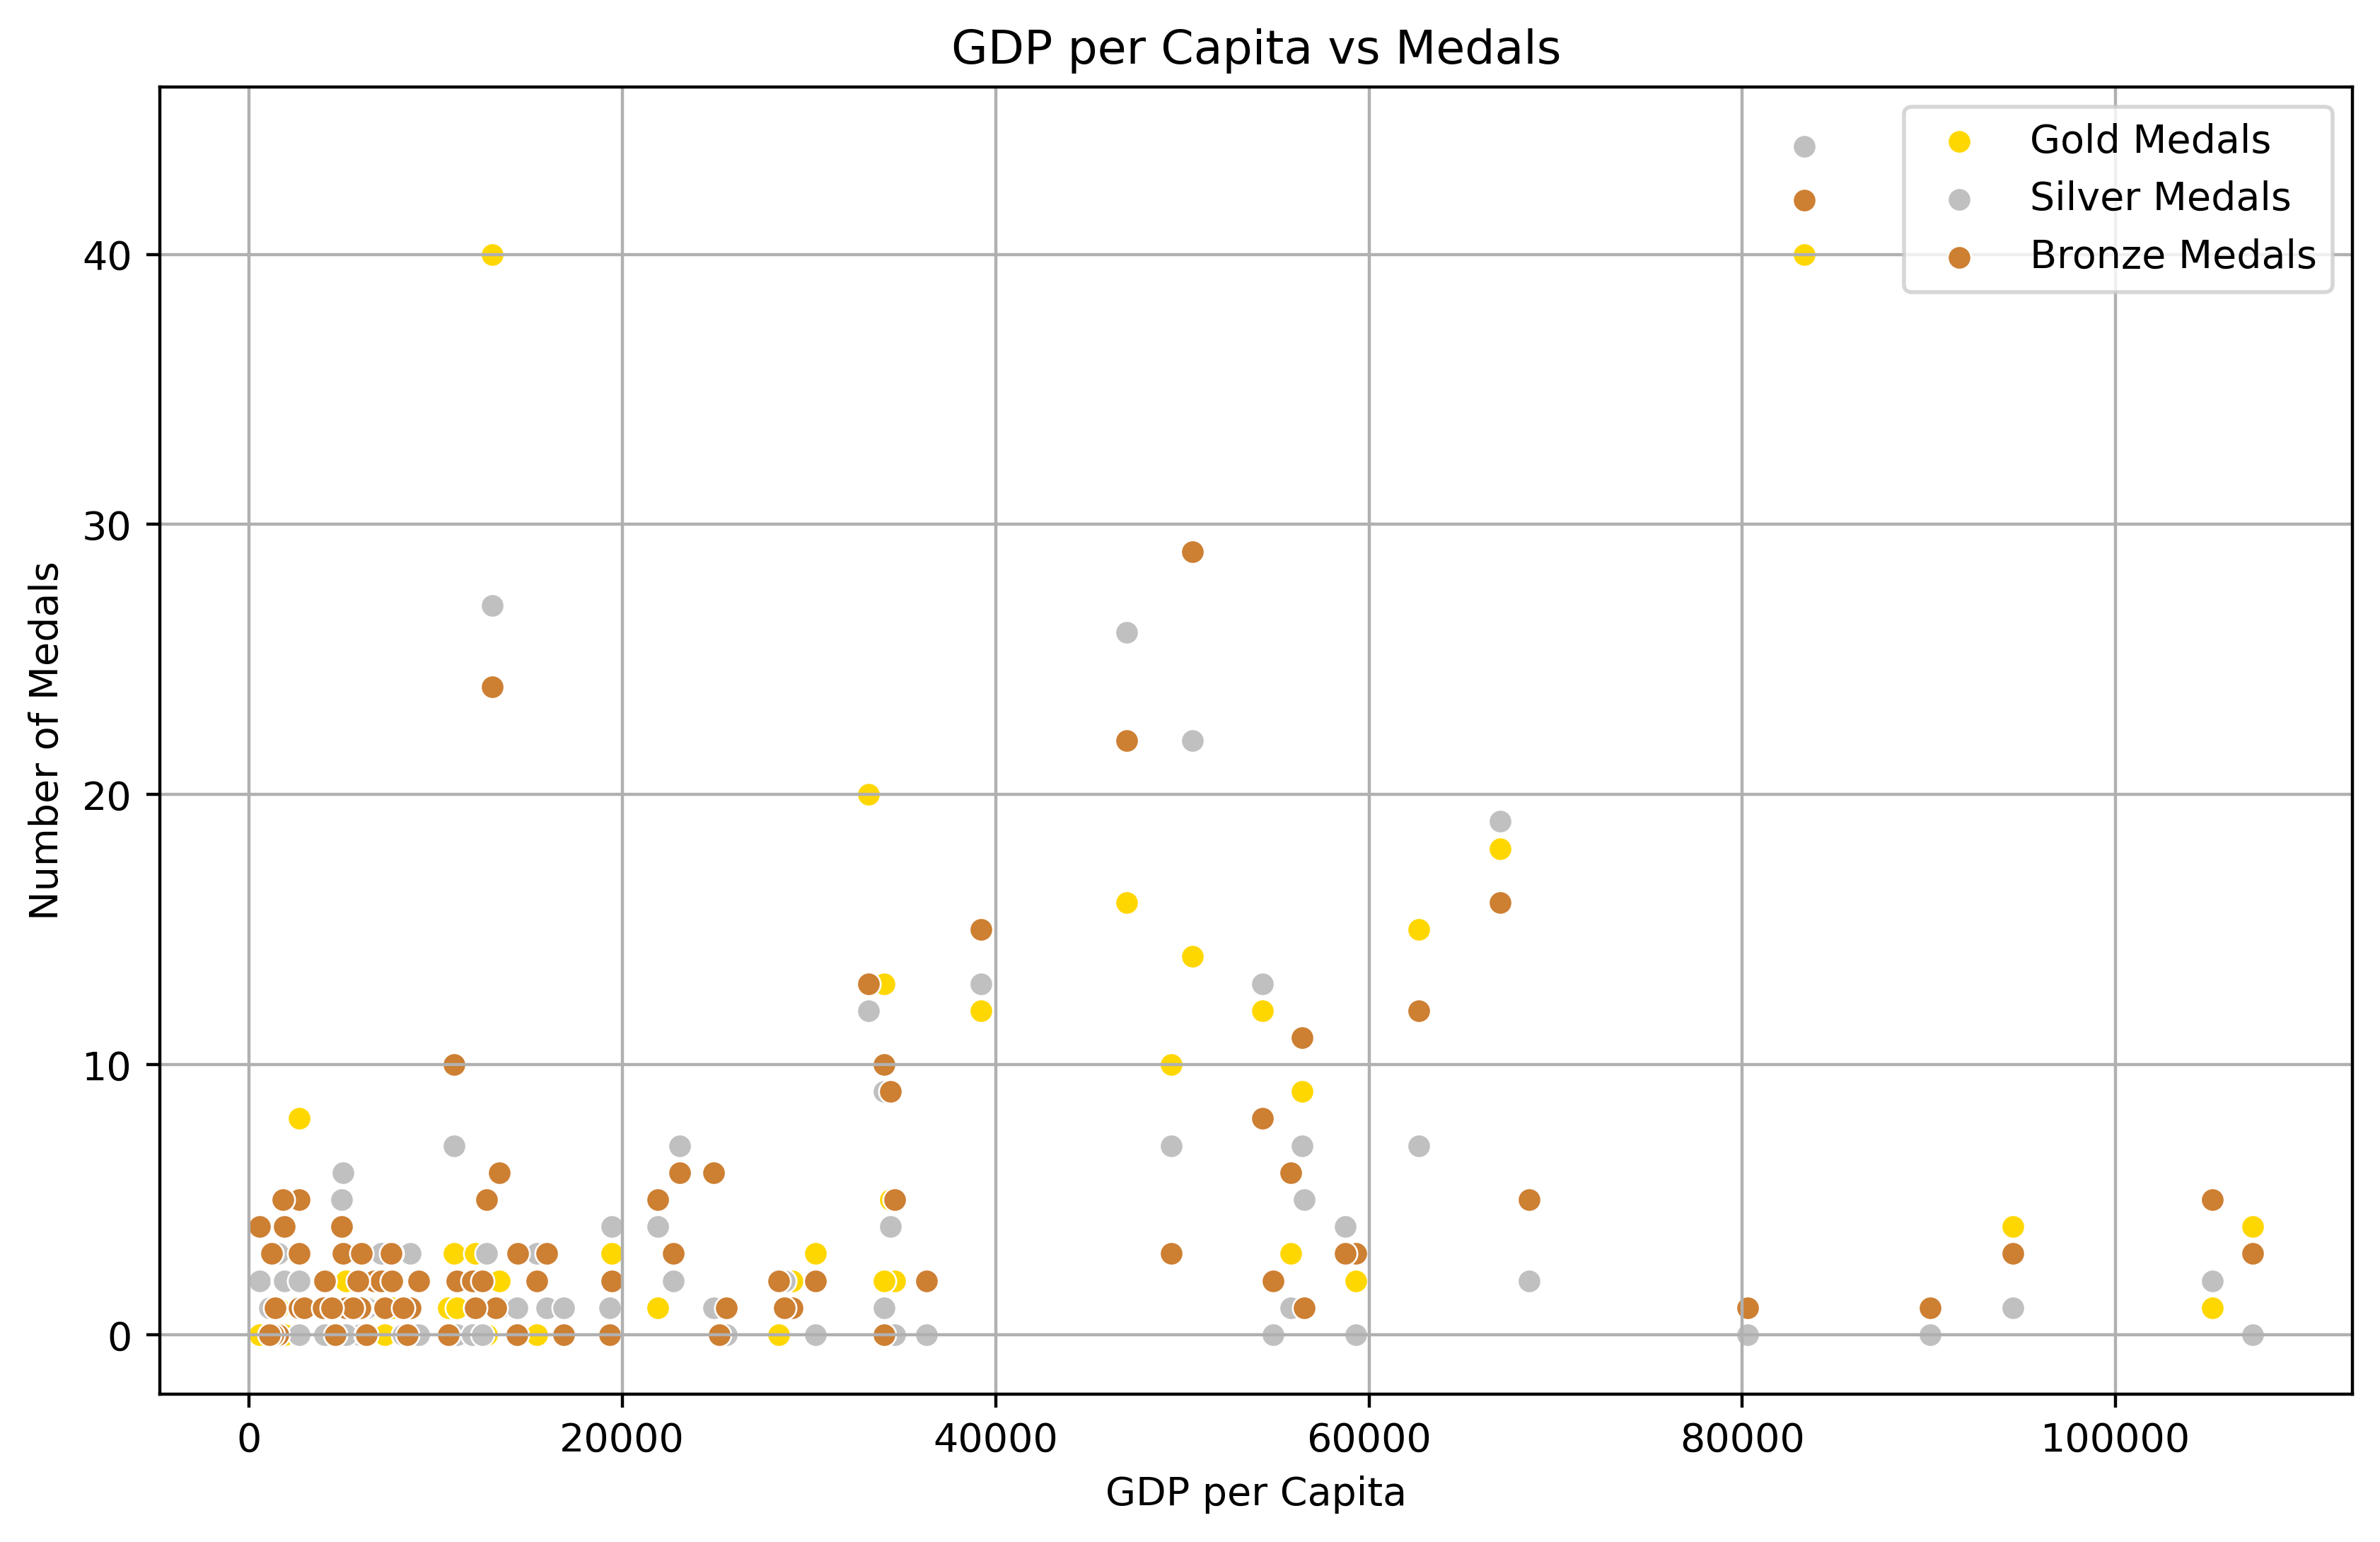

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='gdpPerCapita', y='Gold Medal', color='#FFD700',
                data=medals_population_gdp_2024, label='Gold Medals')
sns.scatterplot(x='gdpPerCapita', y='Silver Medal', color='#C0C0C0',
                data=medals_population_gdp_2024, label='Silver Medals')
sns.scatterplot(x='gdpPerCapita', y='Bronze Medal', color='#CD7F32',
                data=medals_population_gdp_2024, label='Bronze Medals')
plt.title('GDP per Capita vs Medals')
plt.xlabel('GDP per Capita')
plt.ylabel('Number of Medals')
plt.legend(loc='upper right')
plt.grid(True)

In [31]:
medal_distribution_2024_processed.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita
0,Albania,0,0,2,2791765.0,9109.291076
1,Algeria,2,0,1,46814308.0,5698.685111
2,Argentina,1,1,1,45696159.0,13223.430880
3,Armenia,0,3,1,2973840.0,8543.835580
4,Australia,18,19,16,26713205.0,67021.160508


In [32]:
medal_distribution_2024_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       90 non-null     object 
 1   Gold Medal    90 non-null     int64  
 2   Silver Medal  90 non-null     int64  
 3   Bronze Medal  90 non-null     int64  
 4   population    90 non-null     float64
 5   gdpPerCapita  90 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 4.3+ KB


In [33]:
medal_distribution_2024_cc.head()

,country_code,country
0,BEL,Belgium
1,ITA,Italy
2,BEL,Belgium
3,AUS,Australia
4,GBR,Great Britain


In [34]:
medal_distribution_2024_cc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1044 entries, 0 to 2310
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  1044 non-null   object
 1   country       1044 non-null   object
dtypes: object(2)
memory usage: 24.5+ KB


In [35]:
medal_distribution_2024_cc = medal_distribution_2024_cc.drop_duplicates(keep='first')
medal_distribution_2024_cc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 92 entries, 0 to 779
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_code  92 non-null     object
 1   country       92 non-null     object
dtypes: object(2)
memory usage: 2.2+ KB


In [36]:
medal_distribution_2024_country_code = medal_distribution_2024_processed.merge(medal_distribution_2024_cc,
                                                                               on='country', how='left')
medal_distribution_2024_country_code.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,country_code
0,Albania,0,0,2,2791765.0,9109.291076,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,ARM
4,Australia,18,19,16,26713205.0,67021.160508,AUS


In [37]:
medal_distribution_2024_country_code.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   country       90 non-null     object 
 1   Gold Medal    90 non-null     int64  
 2   Silver Medal  90 non-null     int64  
 3   Bronze Medal  90 non-null     int64  
 4   population    90 non-null     float64
 5   gdpPerCapita  90 non-null     float64
 6   country_code  90 non-null     object 
dtypes: float64(2), int64(3), object(2)
memory usage: 5.1+ KB


In [38]:
medal_distribution_2020 = pd.read_csv('../data/raw/2020_Tokyo_Olympics_Nations_Medals.csv')
medal_distribution_2020

,NOC,Gold,Silver,Bronze,Total
0,USA,39,41,33,113
1,CHN,38,32,19,89
2,JPN,27,14,17,58
3,GBR,22,20,22,64
4,ROC,20,28,23,71
...,...,...,...,...,...
87,MDA,0,0,1,1
88,CIV,0,0,1,1
89,BOT,0,0,1,1
90,GHA,0,0,1,1


In [39]:
medal_distribution_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     92 non-null     object
 1   Gold    92 non-null     int64 
 2   Silver  92 non-null     int64 
 3   Bronze  92 non-null     int64 
 4   Total   92 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.7+ KB


In [40]:
medal_distribution_2024_2020 = medal_distribution_2024_country_code.merge(medal_distribution_2020,
                                                                          left_on='country_code',
                                                                          right_on='NOC',
                                                                          how='left')
medal_distribution_2024_2020.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,ALG,NaN,NaN,NaN,NaN,NaN
2,Argentina,1,1,1,45696159.0,13223.430880,ARG,ARG,0.0,1.0,2.0,3.0
3,Armenia,0,3,1,2973840.0,8543.835580,ARM,ARM,0.0,2.0,2.0,4.0
4,Australia,18,19,16,26713205.0,67021.160508,AUS,AUS,17.0,7.0,22.0,46.0


In [41]:
medal_distribution_2024_2020[medal_distribution_2024_2020['NOC'].isna()]

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,ALG,NaN,NaN,NaN,NaN,NaN
12,Cabo Verde,0,0,1,524877.0,5178.356072,CPV,NaN,NaN,NaN,NaN,NaN
14,Chile,1,1,0,19764771.0,16886.611031,CHI,NaN,NaN,NaN,NaN,NaN
20,Cyprus,0,1,0,1358282.0,25194.326362,CYP,NaN,NaN,NaN,NaN,NaN
23,DPR Korea,0,2,4,26498823.0,572.709762,PRK,NaN,NaN,NaN,NaN,NaN
25,Dominica,1,0,0,66205.0,10694.056340,DMA,NaN,NaN,NaN,NaN,NaN
37,Guatemala,1,0,1,18406359.0,5978.097026,GUA,NaN,NaN,NaN,NaN,NaN
44,Israel,1,5,1,9387021.0,56531.672828,ISR,NaN,NaN,NaN,NaN,NaN
62,Pakistan,1,0,0,251269164.0,1300.583911,PAK,NaN,NaN,NaN,NaN,NaN


In [42]:
medal_distribution_2024_2020.fillna(0, inplace=True)
medal_distribution_2024_2020 = medal_distribution_2024_2020[
    ['country', 'Gold Medal', 'Silver Medal', 'Bronze Medal',
     'population', 'gdpPerCapita', 'Gold', 'Silver', 'Bronze', 'country_code']
]
medal_distribution_2024_2020.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold,Silver,Bronze,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,AUS


In [43]:
medal_distribution_2024_2020.rename(columns={'Gold': 'Gold 2020',
                                             'Silver': 'Silver 2020',
                                             'Bronze': 'Bronze 2020'}, inplace=True)
medal_distribution_2024_2020.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,AUS


In [44]:
medal_distribution_2016 = pd.read_csv('../data/raw/2016_Rio_Olympics_Nations_Medals.csv')
medal_distribution_2016

,NOC,Gold,Silver,Bronze,Total
0,USA,46,37,38,121
1,GBR,27,23,17,67
2,CHN,26,18,26,70
3,RUS,19,17,20,56
4,GER,17,10,15,42
...,...,...,...,...,...
80,UAE,0,0,1,1
81,AUT,0,0,1,1
82,POR,0,0,1,1
83,FIN,0,0,1,1


In [45]:
medal_distribution_2016.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     85 non-null     object
 1   Gold    85 non-null     int64 
 2   Silver  85 non-null     int64 
 3   Bronze  85 non-null     int64 
 4   Total   85 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.4+ KB


In [46]:
medal_distribution_2024_2020_2016 = medal_distribution_2024_2020.merge(medal_distribution_2016,
                                                                       left_on='country_code',
                                                                       right_on='NOC',
                                                                       how='left')
medal_distribution_2024_2020_2016.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,ALG,ALG,0.0,2.0,0.0,2.0
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,ARG,ARG,3.0,1.0,0.0,4.0
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,ARM,ARM,1.0,3.0,0.0,4.0
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,AUS,AUS,8.0,11.0,10.0,29.0


In [47]:
medal_distribution_2024_2020_2016[medal_distribution_2024_2020_2016['NOC'].isna()]

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
9,Botswana,1,1,0,2521139.0,8495.366578,0.0,0.0,1.0,BOT,NaN,NaN,NaN,NaN,NaN
12,Cabo Verde,0,0,1,524877.0,5178.356072,0.0,0.0,0.0,CPV,NaN,NaN,NaN,NaN,NaN
14,Chile,1,1,0,19764771.0,16886.611031,0.0,0.0,0.0,CHI,NaN,NaN,NaN,NaN,NaN
20,Cyprus,0,1,0,1358282.0,25194.326362,0.0,0.0,0.0,CYP,NaN,NaN,NaN,NaN,NaN
25,Dominica,1,0,0,66205.0,10694.056340,0.0,0.0,0.0,DMA,NaN,NaN,NaN,NaN,NaN
27,Ecuador,1,2,2,18135478.0,6704.648204,2.0,1.0,0.0,ECU,NaN,NaN,NaN,NaN,NaN
37,Guatemala,1,0,1,18406359.0,5978.097026,0.0,0.0,0.0,GUA,NaN,NaN,NaN,NaN,NaN
38,"Hong Kong, China",2,0,2,7414909.0,54859.068399,1.0,2.0,3.0,HKG,NaN,NaN,NaN,NaN,NaN
44,Israel,1,5,1,9387021.0,56531.672828,0.0,0.0,0.0,ISR,NaN,NaN,NaN,NaN,NaN


In [48]:
medal_distribution_2024_2020_2016.fillna(0, inplace=True)
medal_distribution_2024_2020_2016 = medal_distribution_2024_2020_2016[
    ['country', 'Gold Medal', 'Silver Medal', 'Bronze Medal',
     'population', 'gdpPerCapita', 'Gold 2020', 'Silver 2020', 'Bronze 2020',
     'Gold', 'Silver', 'Bronze', 'country_code']
]
medal_distribution_2024_2020_2016.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold,Silver,Bronze,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,AUS


In [49]:
medal_distribution_2024_2020_2016.rename(columns={'Gold': 'Gold 2016',
                                                  'Silver': 'Silver 2016',
                                                  'Bronze': 'Bronze 2016'}, inplace=True)
medal_distribution_2024_2020_2016.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,AUS


In [50]:
medal_distribution_2012 = pd.read_csv('../data/raw/2012_London_Olympics_Nations_Medals.csv')
medal_distribution_2012

,NOC,Gold,Silver,Bronze,Total
0,USA,48,26,30,104
1,CHN,39,31,22,92
2,GBR,29,18,18,65
3,RUS,18,21,26,65
4,KOR,13,9,9,31
...,...,...,...,...,...
81,KUW,0,0,1,1
82,HKG,0,0,1,1
83,CMR,0,0,1,1
84,KSA,0,0,1,1


In [51]:
medal_distribution_2012.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     86 non-null     object
 1   Gold    86 non-null     int64 
 2   Silver  86 non-null     int64 
 3   Bronze  86 non-null     int64 
 4   Total   86 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.5+ KB


In [52]:
medal_distribution_2024_2020_2016_2012 = medal_distribution_2024_2020_2016.merge(medal_distribution_2012,
                                                                                 left_on='country_code',
                                                                                 right_on='NOC',
                                                                                 how='left')
medal_distribution_2024_2020_2016_2012.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,ALG,ALG,1.0,0.0,0.0,1.0
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,ARG,ARG,1.0,1.0,2.0,4.0
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,ARM,ARM,0.0,1.0,1.0,2.0
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,AUS,AUS,8.0,15.0,12.0,35.0


In [53]:
medal_distribution_2024_2020_2016_2012[medal_distribution_2024_2020_2016_2012['NOC'].isna()]

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
5,Austria,2,0,3,9120813.0,59302.498582,1.0,1.0,5.0,0.0,0.0,1.0,AUT,NaN,NaN,NaN,NaN,NaN
12,Cabo Verde,0,0,1,524877.0,5178.356072,0.0,0.0,0.0,0.0,0.0,0.0,CPV,NaN,NaN,NaN,NaN,NaN
14,Chile,1,1,0,19764771.0,16886.611031,0.0,0.0,0.0,0.0,0.0,0.0,CHI,NaN,NaN,NaN,NaN,NaN
22,Côte d'Ivoire,0,0,1,31934230.0,2721.562411,0.0,0.0,1.0,1.0,0.0,1.0,CIV,NaN,NaN,NaN,NaN,NaN
25,Dominica,1,0,0,66205.0,10694.056340,0.0,0.0,0.0,0.0,0.0,0.0,DMA,NaN,NaN,NaN,NaN,NaN
27,Ecuador,1,2,2,18135478.0,6704.648204,2.0,1.0,0.0,0.0,0.0,0.0,ECU,NaN,NaN,NaN,NaN,NaN
30,Fiji,0,1,0,928784.0,6245.800961,1.0,0.0,1.0,1.0,0.0,0.0,FIJ,NaN,NaN,NaN,NaN,NaN
44,Israel,1,5,1,9387021.0,56531.672828,0.0,0.0,0.0,0.0,0.0,0.0,ISR,NaN,NaN,NaN,NaN,NaN
48,Jordan,0,1,0,11552876.0,4636.940620,0.0,1.0,1.0,1.0,0.0,0.0,JOR,NaN,NaN,NaN,NaN,NaN


In [54]:
medal_distribution_2024_2020_2016_2012.fillna(0, inplace=True)
medal_distribution_2024_2020_2016_2012 = medal_distribution_2024_2020_2016_2012[
    ['country', 'Gold Medal', 'Silver Medal', 'Bronze Medal',
     'population', 'gdpPerCapita', 'Gold 2020', 'Silver 2020', 'Bronze 2020',
     'Gold 2016', 'Silver 2016', 'Bronze 2016',
     'Gold', 'Silver', 'Bronze', 'country_code']
]
medal_distribution_2024_2020_2016_2012.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,Gold,Silver,Bronze,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,1.0,1.0,2.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,0.0,1.0,1.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,8.0,15.0,12.0,AUS


In [55]:
medal_distribution_2024_2020_2016_2012.rename(columns={'Gold': 'Gold 2012',
                                                       'Silver': 'Silver 2012',
                                                       'Bronze': 'Bronze 2012'}, inplace=True)
medal_distribution_2024_2020_2016_2012.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,1.0,1.0,2.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,0.0,1.0,1.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,8.0,15.0,12.0,AUS


In [56]:
medal_distribution_2008 = pd.read_csv('../data/raw/2008_Beijing_Olympics_Nations_Medals.csv')
medal_distribution_2008

,NOC,Gold,Silver,Bronze,Total
0,AFG,0,0,1,1
1,ALG,0,1,1,2
2,ARG,2,0,4,6
3,ARM,0,1,4,5
4,AUS,14,15,17,46
...,...,...,...,...,...
82,USA,36,39,37,112
83,UZB,0,1,3,4
84,VEN,0,0,1,1
85,VIE,0,1,0,1


In [57]:
medal_distribution_2008.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     87 non-null     object
 1   Gold    87 non-null     int64 
 2   Silver  87 non-null     int64 
 3   Bronze  87 non-null     int64 
 4   Total   87 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.5+ KB


In [58]:
medal_distribution_2024_2020_2016_2012_2008 = medal_distribution_2024_2020_2016_2012.merge(medal_distribution_2008,
                                                                                           left_on='country_code',
                                                                                           right_on='NOC',
                                                                                           how='left')
medal_distribution_2024_2020_2016_2012_2008.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,ALG,ALG,0.0,1.0,1.0,2.0
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,...,0.0,1.0,1.0,2.0,ARG,ARG,2.0,0.0,4.0,6.0
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,0.0,0.0,1.0,1.0,ARM,ARM,0.0,1.0,4.0,5.0
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,...,10.0,8.0,15.0,12.0,AUS,AUS,14.0,15.0,17.0,46.0


In [59]:
medal_distribution_2024_2020_2016_2012_2008[medal_distribution_2024_2020_2016_2012_2008['NOC'].isna()]

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
7,Bahrain,2,1,1,1607049.0,29115.478122,0.0,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,BRN,NaN,NaN,NaN,NaN,NaN
9,Botswana,1,1,0,2521139.0,8495.366578,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,BOT,NaN,NaN,NaN,NaN,NaN
12,Cabo Verde,0,0,1,524877.0,5178.356072,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,CPV,NaN,NaN,NaN,NaN,NaN
20,Cyprus,0,1,0,1358282.0,25194.326362,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,CYP,NaN,NaN,NaN,NaN,NaN
22,Côte d'Ivoire,0,0,1,31934230.0,2721.562411,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,CIV,NaN,NaN,NaN,NaN,NaN
25,Dominica,1,0,0,66205.0,10694.056340,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,DMA,NaN,NaN,NaN,NaN,NaN
30,Fiji,0,1,0,928784.0,6245.800961,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,FIJ,NaN,NaN,NaN,NaN,NaN
36,Grenada,0,0,2,117207.0,11995.870554,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,GRN,NaN,NaN,NaN,NaN,NaN
37,Guatemala,1,0,1,18406359.0,5978.097026,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,GUA,NaN,NaN,NaN,NaN,NaN


In [60]:
medal_distribution_2024_2020_2016_2012_2008.fillna(0, inplace=True)
medal_distribution_2024_2020_2016_2012_2008 = medal_distribution_2024_2020_2016_2012_2008[
    ['country', 'Gold Medal', 'Silver Medal', 'Bronze Medal',
     'population', 'gdpPerCapita', 'Gold 2020', 'Silver 2020', 'Bronze 2020',
     'Gold 2016', 'Silver 2016', 'Bronze 2016',
     'Gold 2012', 'Silver 2012', 'Bronze 2012',
     'Gold', 'Silver', 'Bronze', 'country_code']
]
medal_distribution_2024_2020_2016_2012_2008.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,Gold,Silver,Bronze,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,1.0,1.0,2.0,2.0,0.0,4.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,0.0,1.0,1.0,0.0,1.0,4.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,8.0,15.0,12.0,14.0,15.0,17.0,AUS


In [61]:
medal_distribution_2024_2020_2016_2012_2008.rename(columns={'Gold': 'Gold 2008',
                                                            'Silver': 'Silver 2008',
                                                            'Bronze': 'Bronze 2008'}, inplace=True)
medal_distribution_2024_2020_2016_2012_2008.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,Silver 2016,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,1.0,0.0,1.0,1.0,2.0,2.0,0.0,4.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,3.0,0.0,0.0,1.0,1.0,0.0,1.0,4.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,11.0,10.0,8.0,15.0,12.0,14.0,15.0,17.0,AUS


In [62]:
medal_distribution_2004 = pd.read_csv('../data/raw/2004_Athens_Olympics_Nations_Medals.csv')
medal_distribution_2004

,NOC,Gold,Silver,Bronze,Total
0,USA,36,39,26,101
1,CHN,32,17,15,64
2,RUS,28,26,36,90
3,AUS,17,16,17,50
4,JPN,16,9,12,37
...,...,...,...,...,...
69,VEN,0,0,2,2
70,SYR,0,0,1,1
71,TTO,0,0,1,1
72,ERI,0,0,1,1


In [63]:
medal_distribution_2004.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   NOC     74 non-null     object
 1   Gold    74 non-null     int64 
 2   Silver  74 non-null     int64 
 3   Bronze  74 non-null     int64 
 4   Total   74 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.0+ KB


In [64]:
medal_distribution_2024_2020_2016_2012_2008_2004 = medal_distribution_2024_2020_2016_2012_2008.merge(medal_distribution_2004,
                                                                                                     left_on='country_code',
                                                                                                     right_on='NOC',
                                                                                                     how='left')
medal_distribution_2024_2020_2016_2012_2008_2004.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,ALG,NaN,NaN,NaN,NaN,NaN
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,...,2.0,2.0,0.0,4.0,ARG,ARG,2.0,0.0,4.0,6.0
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,1.0,0.0,1.0,4.0,ARM,NaN,NaN,NaN,NaN,NaN
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,...,12.0,14.0,15.0,17.0,AUS,AUS,17.0,16.0,17.0,50.0


In [65]:
medal_distribution_2024_2020_2016_2012_2008_2004[medal_distribution_2024_2020_2016_2012_2008_2004['NOC'].isna()]

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,country_code,NOC,Gold,Silver,Bronze,Total
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,ALB,NaN,NaN,NaN,NaN,NaN
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,ALG,NaN,NaN,NaN,NaN,NaN
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,1.0,0.0,1.0,4.0,ARM,NaN,NaN,NaN,NaN,NaN
7,Bahrain,2,1,1,1607049.0,29115.478122,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,BRN,NaN,NaN,NaN,NaN,NaN
9,Botswana,1,1,0,2521139.0,8495.366578,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,BOT,NaN,NaN,NaN,NaN,NaN
12,Cabo Verde,0,0,1,524877.0,5178.356072,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,CPV,NaN,NaN,NaN,NaN,NaN
20,Cyprus,0,1,0,1358282.0,25194.326362,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,CYP,NaN,NaN,NaN,NaN,NaN
22,Côte d'Ivoire,0,0,1,31934230.0,2721.562411,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,CIV,NaN,NaN,NaN,NaN,NaN
25,Dominica,1,0,0,66205.0,10694.056340,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,DMA,NaN,NaN,NaN,NaN,NaN
27,Ecuador,1,2,2,18135478.0,6704.648204,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,ECU,NaN,NaN,NaN,NaN,NaN


In [66]:
medal_distribution_2024_2020_2016_2012_2008_2004.fillna(0, inplace=True)
medal_distribution_2024_2020_2016_2012_2008_2004 = medal_distribution_2024_2020_2016_2012_2008_2004[
    ['country', 'Gold Medal', 'Silver Medal', 'Bronze Medal',
     'population', 'gdpPerCapita', 'Gold 2020', 'Silver 2020', 'Bronze 2020',
     'Gold 2016', 'Silver 2016', 'Bronze 2016',
     'Gold 2012', 'Silver 2012', 'Bronze 2012',
     'Gold 2008', 'Silver 2008', 'Bronze 2008',
     'Gold', 'Silver', 'Bronze', 'country_code']
]
medal_distribution_2024_2020_2016_2012_2008_2004.head()

,country,Gold Medal,Silver Medal,Bronze Medal,population,gdpPerCapita,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Gold 2012,Silver 2012,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,Gold,Silver,Bronze,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,...,1.0,1.0,2.0,2.0,0.0,4.0,2.0,0.0,4.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,0.0,1.0,1.0,0.0,1.0,4.0,0.0,0.0,0.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,...,8.0,15.0,12.0,14.0,15.0,17.0,17.0,16.0,17.0,AUS


In [67]:
medal_distribution_2024_2020_2016_2012_2008_2004.rename(columns={'Gold Medal': 'Gold 2024',
                                                                 'Silver Medal': 'Silver 2024',
                                                                 'Bronze Medal': 'Bronze 2024',
                                                                 'population': 'Population 2024',
                                                                 'gdpPerCapita': 'GDP 2024',
                                                                 'Gold': 'Gold 2008',
                                                                 'Silver': 'Silver 2008',
                                                                 'Bronze': 'Bronze 2008'}, inplace=True)
medal_distribution_2024_2020_2016_2012_2008_2004.head()

,country,Gold 2024,Silver 2024,Bronze 2024,Population 2024,GDP 2024,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Gold 2012,Silver 2012,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,Gold 2008,Silver 2008,Bronze 2008,country_code
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ALB
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,ALG
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,...,1.0,1.0,2.0,2.0,0.0,4.0,2.0,0.0,4.0,ARG
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,0.0,1.0,1.0,0.0,1.0,4.0,0.0,0.0,0.0,ARM
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,...,8.0,15.0,12.0,14.0,15.0,17.0,17.0,16.0,17.0,AUS


In [68]:
medal_distribution_2024_2020_2016_2012_2008_2004 = medal_distribution_2024_2020_2016_2012_2008_2004.iloc[:,:-1]
medal_distribution_2024_2020_2016_2012_2008_2004.head()

,country,Gold 2024,Silver 2024,Bronze 2024,Population 2024,GDP 2024,Gold 2020,Silver 2020,Bronze 2020,Gold 2016,...,Bronze 2016,Gold 2012,Silver 2012,Bronze 2012,Gold 2008,Silver 2008,Bronze 2008,Gold 2008,Silver 2008,Bronze 2008
0,Albania,0,0,2,2791765.0,9109.291076,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Algeria,2,0,1,46814308.0,5698.685111,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,Argentina,1,1,1,45696159.0,13223.430880,0.0,1.0,2.0,3.0,...,0.0,1.0,1.0,2.0,2.0,0.0,4.0,2.0,0.0,4.0
3,Armenia,0,3,1,2973840.0,8543.835580,0.0,2.0,2.0,1.0,...,0.0,0.0,1.0,1.0,0.0,1.0,4.0,0.0,0.0,0.0
4,Australia,18,19,16,26713205.0,67021.160508,17.0,7.0,22.0,8.0,...,10.0,8.0,15.0,12.0,14.0,15.0,17.0,17.0,16.0,17.0


In [69]:
medal_distribution_2024_2020_2016_2012_2008_2004.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          90 non-null     object 
 1   Gold 2024        90 non-null     int64  
 2   Silver 2024      90 non-null     int64  
 3   Bronze 2024      90 non-null     int64  
 4   Population 2024  90 non-null     float64
 5   GDP 2024         90 non-null     float64
 6   Gold 2020        90 non-null     float64
 7   Silver 2020      90 non-null     float64
 8   Bronze 2020      90 non-null     float64
 9   Gold 2016        90 non-null     float64
 10  Silver 2016      90 non-null     float64
 11  Bronze 2016      90 non-null     float64
 12  Gold 2012        90 non-null     float64
 13  Silver 2012      90 non-null     float64
 14  Bronze 2012      90 non-null     float64
 15  Gold 2008        90 non-null     float64
 16  Silver 2008      90 non-null     float64
 17  Bronze 2008      9

In [70]:
folder_path = '../data/processed/'
file_name = 'medals_population_gdp_2024_2004_processed.csv'
full_path = folder_path + file_name
medal_distribution_2024_2020_2016_2012_2008_2004.to_csv(full_path)

## Clustering Analysis

In this part, we will use K-Means clustering and Principal Component Analysis (PCA) to group 2024 medal-winning countries based on their historical medal performance over the last five Summer Olympics and socioeconomic factors using Olympic medal data.

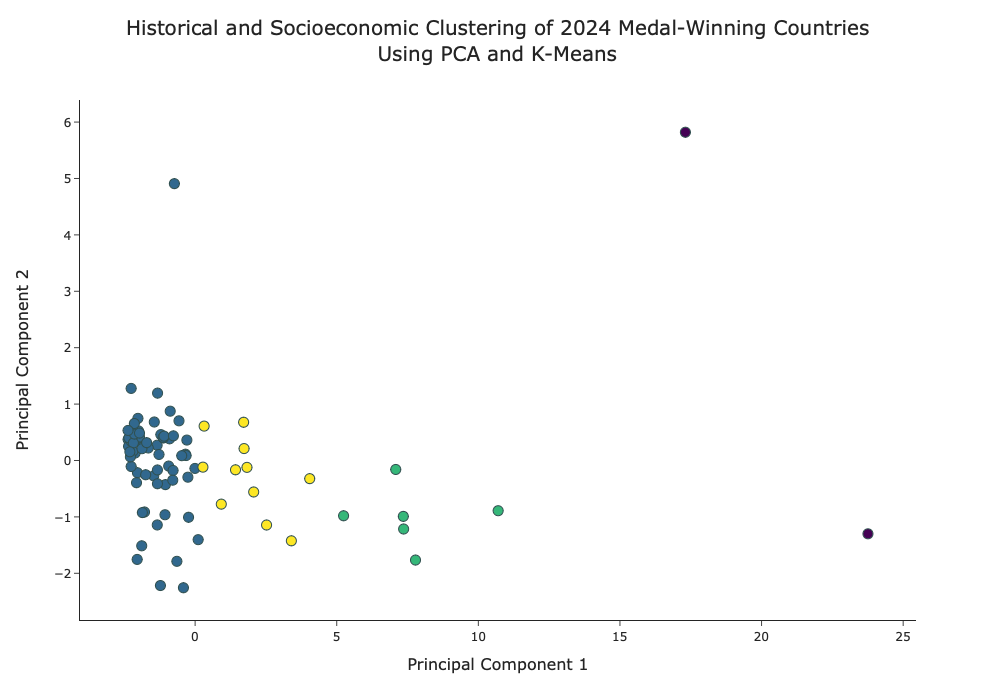

In [198]:
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def preprocess_data(data):
    """Standardize the data."""
    scaler = StandardScaler()
    return scaler.fit_transform(data)

def perform_pca(scaled_data, n_components=2):
    """Apply PCA for dimensionality reduction."""
    pca = PCA(n_components=n_components)
    return pca.fit_transform(scaled_data)

def apply_kmeans(scaled_data, n_clusters=4, n_init=10, random_state=42):
    """Apply K-Means clustering."""
    kmeans = KMeans(n_clusters=n_clusters, n_init=n_init, random_state=random_state)
    return kmeans.fit_predict(scaled_data)

def create_pca_dataframe(pca_data, clusters, country_names):
    """Create a DataFrame with PCA results and cluster labels."""
    pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
    pca_df['Cluster'] = clusters
    pca_df['Country'] = country_names
    return pca_df

def visualize_clusters(pca_df):
    """Visualize K-Means clusters on a PCA plot."""
    fig = px.scatter(
        pca_df,
        x='PC1',
        y='PC2',
        color='Cluster',
        hover_name='Country',
        title='Historical and Socioeconomic Clustering of 2024 Medal-Winning Countries<br>Using PCA and K-Means',
        labels={'PC1': 'Principal Component 1', 'PC2': 'Principal Component 2'},
        template='simple_white',
        height=700,
        width=1000,
        color_discrete_sequence=px.colors.qualitative.Vivid,
    )

    fig.update_traces(marker=dict(size=10, line=dict(width=1, color='DarkSlateGrey')),
                      selector=dict(mode='markers'))

    fig.update_layout(
        title_font_size=20,
        title_x=0.5,
        title_y=0.95,
        xaxis_title_font_size=16,
        yaxis_title_font_size=16,
        showlegend=False,
        coloraxis_showscale=False,
    )

    fig.show()

def main(data, n_clusters=4):
    """Main function to execute the analysis."""
    # Step 1: Standardize the data
    scaled_data = preprocess_data(data.iloc[:, 1:])

    # Step 2: Apply PCA for dimensionality reduction
    pca_data = perform_pca(scaled_data)

    # Step 3: Apply K-Means clustering
    clusters = apply_kmeans(scaled_data, n_clusters=n_clusters)

    # Step 4: Create a DataFrame for PCA components and clusters
    pca_df = create_pca_dataframe(pca_data, clusters, data['country'])

    # Step 5: Visualize the K-Means clusters
    visualize_clusters(pca_df)

main(medal_distribution_2024_2020_2016_2012_2008_2004, n_clusters=4)